In [1]:

from pathlib import Path
import re
import xml.etree.ElementTree as ET
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.metrics.pairwise import cosine_similarity

plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_colwidth', 180)
RANDOM_STATE = 42


In [2]:
import zipfile
from pathlib import Path

ZIP_PATH = Path('/content/15_Suspicious_Passages.zip')
EXTRACT_DIR = Path('/content/extracted_suspicious_data')

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Done")
print(list(EXTRACT_DIR.iterdir())[:10])

Done
[PosixPath('/content/extracted_suspicious_data/15_Suspicious_Passages')]


In [3]:
from pathlib import Path

DATASET_DIR = Path('/content/extracted_suspicious_data/15_Suspicious_Passages/31.Suspicious_Passages')
CORPUS_DIR = DATASET_DIR / 'corpus'
GROUND_TRUTH_PATH = DATASET_DIR / 'ground_truth.tsv'

print("Dataset exists:", DATASET_DIR.exists())
print("Corpus exists:", CORPUS_DIR.exists())
print("Ground truth exists:", GROUND_TRUTH_PATH.exists())
print("Sample files:", [p.name for p in list(CORPUS_DIR.iterdir())[:5]])

Dataset exists: True
Corpus exists: True
Ground truth exists: True
Sample files: ['source-document03867.txt', 'suspicious-document03388.xml', 'source-document06238.txt', 'suspicious-document00803.xml', 'source-document02928.txt']


In [4]:
import pandas as pd
import xml.etree.ElementTree as ET

labels_df = pd.read_csv(GROUND_TRUTH_PATH, sep='\t')
print(labels_df.head())
print(labels_df.columns.tolist())
print(labels_df.shape)

        doc_name  plagiarism
0  document01421           1
1  document00852           0
2  document02154           1
3  document05907           1
4  document06948           1
['doc_name', 'plagiarism']
(902, 2)


In [13]:
def read_text_file(path):
    try:
        return path.read_text(encoding='utf-8')
    except:
        return path.read_text(errors='ignore')

source_map = {}

for p in CORPUS_DIR.iterdir():
    if p.name.startswith("source-") and p.suffix == ".txt":
        key = p.stem.replace("source-", "")  # documentXXXXX
        source_map[key] = read_text_file(p)

In [14]:
labels_df['text'] = labels_df['doc_name'].map(source_map)
labels_df['text'] = labels_df['text'].fillna('')

labels_df['char_length'] = labels_df['text'].apply(len)
labels_df['word_count'] = labels_df['text'].apply(lambda x: len(x.split()))

print(labels_df[['doc_name', 'word_count']].head())
print("Empty rows:", (labels_df['text'] == '').sum())

        doc_name  word_count
0  document01421       67469
1  document00852        1404
2  document02154        4100
3  document05907        2464
4  document06948       29560
Empty rows: 0


In [15]:
summary = {
    'documents': len(labels_df),
    'plagiarized_docs': int(labels_df['plagiarism'].sum()),
    'non_plagiarized_docs': int((1 - labels_df['plagiarism']).sum()),
    'avg_word_count': round(labels_df['word_count'].mean(), 2),
    'median_word_count': round(labels_df['word_count'].median(), 2),
    'min_word_count': int(labels_df['word_count'].min()),
    'max_word_count': int(labels_df['word_count'].max()),
}
summary

{'documents': 902,
 'plagiarized_docs': 451,
 'non_plagiarized_docs': 451,
 'avg_word_count': np.float64(29053.64),
 'median_word_count': 5564.5,
 'min_word_count': 137,
 'max_word_count': 434472}

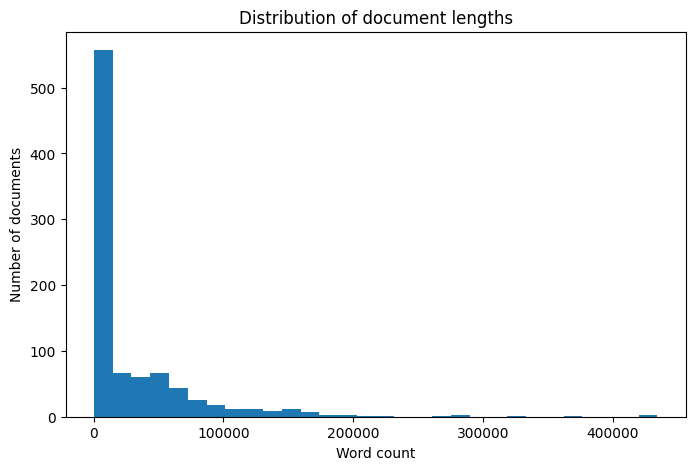

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(labels_df['word_count'], bins=30)
plt.xlabel('Word count')
plt.ylabel('Number of documents')
plt.title('Distribution of document lengths')
plt.show()

In [17]:
labels_df['plagiarism'].value_counts()

,count
plagiarism,
1,451
0,451


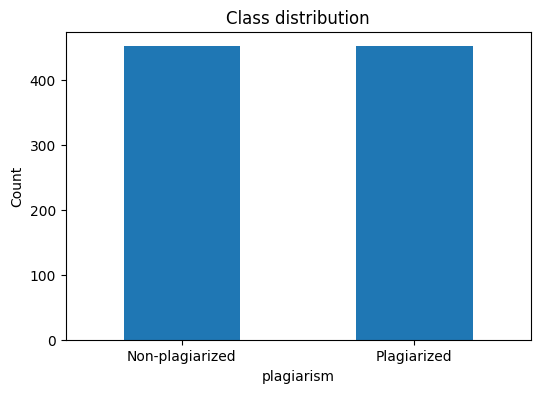

In [18]:
plt.figure(figsize=(6,4))
labels_df['plagiarism'].value_counts().sort_index().plot(kind='bar')
plt.xticks([0, 1], ['Non-plagiarized', 'Plagiarized'], rotation=0)
plt.ylabel('Count')
plt.title('Class distribution')
plt.show()

In [19]:
import re

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

labels_df['clean_text'] = labels_df['text'].apply(preprocess)
labels_df[['doc_name', 'clean_text']].head()

,doc_name,clean_text
0,document01421,produced by stan goodman ted garvin c markus and pg distributed proofreaders epochs of ancient history the gracchi marius and sulla by a h beesley with maps preface it would be...
1,document00852,whether you enjoy the house in marylebone duckworth will depend entirely upon your taste for the society of a number of hardworking but sentimental business girls for this is t...
2,document02154,they were seated on the sofa the black broadcloth coat sleeve encircling the slender waist of the gray traveling dress and the jetty moustache in equally affectionate proximity...
3,document05907,it was at rome on the th of october as i sat musing amidst the ruins of the capitol while the barefooted friars were singing vespers in the temple of jupiter that the idea of w...
4,document06948,this ebook was produced by eric eldred the seven who were hanged a story by leonid andreyev authorized translation from the russian bt herman bernstein dedication to count leo ...


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = labels_df['clean_text']
y = labels_df['plagiarism']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1,3))),
    ('clf', LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))
print()
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.574585635359116

              precision    recall  f1-score   support

           0       0.59      0.48      0.53        91
           1       0.56      0.67      0.61        90

    accuracy                           0.57       181
   macro avg       0.58      0.58      0.57       181
weighted avg       0.58      0.57      0.57       181


Confusion matrix:
[[44 47]
 [30 60]]


In [28]:
feature_names = model.named_steps['tfidf'].get_feature_names_out()
coefficients = model.named_steps['clf'].coef_[0]

top_positive_idx = coefficients.argsort()[-15:][::-1]
top_negative_idx = coefficients.argsort()[:15]

print("Top terms indicating plagiarism:")
for i in top_positive_idx:
    print(feature_names[i], round(coefficients[i], 3))

print("\nTop terms indicating non-plagiarism:")
for i in top_negative_idx:
    print(feature_names[i], round(coefficients[i], 3))

Top terms indicating plagiarism:
is 0.797
would 0.584
ch 0.562
has 0.528
that 0.491
and 0.488
it 0.469
in 0.457
have 0.449
sir 0.436
im 0.434
the 0.422
kt 0.36
from 0.355
ich 0.348

Top terms indicating non-plagiarism:
we -0.55
tom -0.496
me -0.437
our -0.412
lanyard -0.41
said -0.389
illustration -0.385
est -0.381
fig -0.372
they -0.356
the king -0.354
vo -0.35
harry -0.33
him -0.325
na -0.324


Plagiarism check

In [34]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def make_windows(text, window_size=50, step=25):
    words = text.split()
    windows = []
    for i in range(0, max(len(words) - window_size + 1, 1), step):
        chunk = " ".join(words[i:i+window_size])
        windows.append((i, chunk))
    return windows

In [44]:
susp_windows = make_windows(preprocess(suspicious_text), window_size=50, step=25)
src_windows = make_windows(preprocess(source_text), window_size=50, step=25)

all_chunks = [w[1] for w in susp_windows] + [w[1] for w in src_windows]

vectorizer = TfidfVectorizer(ngram_range=(1,2), stop_words='english')
X = vectorizer.fit_transform(all_chunks)

n_susp = len(susp_windows)
X_susp = X[:n_susp]
X_src = X[n_susp:]

sim = cosine_similarity(X_susp, X_src)

In [53]:
matches = []

for i in range(sim.shape[0]):
    j = sim[i].argmax()
    score = sim[i, j]
    matches.append({
        'susp_window_start_word': susp_windows[i][0],
        'source_window_start_word': src_windows[j][0],
        'similarity': float(score),
        'susp_text': susp_windows[i][1],
        'source_text': src_windows[j][1]
    })

matches_df = pd.DataFrame(matches).sort_values('similarity', ascending=False)
print(matches_df[['susp_window_start_word', 'source_window_start_word', 'similarity']].head(10))

      susp_window_start_word  source_window_start_word  similarity
866                    21650                       925    0.086519
980                    24500                      1075    0.076632
1225                   30625                       850    0.072150
1224                   30600                       850    0.071302
979                    24475                      1075    0.070881
865                    21625                       925    0.066793
2581                   64525                       600    0.062139
340                     8500                        25    0.061890
1054                   26350                       925    0.061744
108                     2700                       350    0.060846


In [54]:
print("Number of matches:", len(matches))

Number of matches: 2718


In [55]:
for _, row in matches_df.head(5).iterrows():
    print("=" * 100)
    print(f"Similarity: {row['similarity']:.3f}")
    print(f"Suspicious start word: {row['susp_window_start_word']}")
    print(f"Source start word: {row['source_window_start_word']}")
    print("\nSuspicious text:\n", row['susp_text'])
    print("\nSource text:\n", row['source_text'])
    print()

Similarity: 0.087
Suspicious start word: 21650
Source start word: 925

Suspicious text:
 of quintus metellus gained the consulship five of the six gained triumphs and one was censor while he himself had filled all the highest offices of the state thus as sallust says the nobles passed on the chief dignities from hand to hand there must have been many of the

Source text:
 altogether too foolish a travesty of a man ever to have gained her hand or having gained it to have held it against any real male in or out of khaki the fact is that bertha ruck can achieve something better than these meandering methods and this spinelessness of characterisation

Similarity: 0.077
Suspicious start word: 24500
Source start word: 1075

Suspicious text:
 who was next sent against him was playing the game of scaurus and bestia over again for he effected nothing in his campaign in nor does his brother s rashness exonerate him left as propraetor in charge of the army this man in january determined to try an

New Code

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# use all documents (or subset if slow)
texts = labels_df['clean_text']
doc_names = labels_df['doc_name'].tolist()

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(texts)

sim_matrix = cosine_similarity(X)

In [57]:
import numpy as np

np.fill_diagonal(sim_matrix, -1)  # ignore self-similarity

# get top similar pairs
pairs = []

for i in range(len(doc_names)):
    j = sim_matrix[i].argmax()
    pairs.append((doc_names[i], doc_names[j], sim_matrix[i, j]))

pairs_df = pd.DataFrame(pairs, columns=['doc1', 'doc2', 'similarity'])
pairs_df = pairs_df.sort_values(by='similarity', ascending=False)

pairs_df.head(10)

,doc1,doc2,similarity
472,document04042,document04086,0.989538
14,document04086,document04042,0.989538
629,document03507,document04042,0.988269
455,document06722,document01170,0.982936
218,document01170,document06722,0.982936
187,document05220,document03507,0.981352
418,document04248,document03507,0.980065
589,document02408,document02831,0.974752
890,document02831,document02408,0.974752
11,document01630,document01170,0.973445


In [58]:
top_pair = pairs_df.iloc[0]

doc1 = top_pair['doc1']
doc2 = top_pair['doc2']

print("Most similar documents:")
print(doc1, doc2)
print("Similarity:", top_pair['similarity'])

print("\n--- TEXT 1 ---\n")
print(source_map.get(doc1, "")[:500])

print("\n--- TEXT 2 ---\n")
print(source_map.get(doc2, "")[:500])

Most similar documents:
document04042 document04086
Similarity: 0.9895380236499127

--- TEXT 1 ---

﻿Calais. Cong. Ch. and Soc.                   45.00

Foxcroft. Mrs. D. Blanchard                   1.00

Harpswell. Cong Ch., 18; Sab. Sch. of
  Cong. Ch., for Indian M., 4                22.00

Portland. King's Daughters, by Miss
  Moniton, Sec., Box of Basted Work and
  1 doz. thimbles, for Selma, Ala.

South Berwick. Mrs. K.B. Lewis, 3.50;
  "A Lady in Neb." by John H. Plumer, 2       5.50

Union. Cong. Ch. and Soc.                     7.00

Winslow. S.S. of Cong. Ch.                   10.00


--- TEXT 2 ---

﻿    West Brattleboro. Ladies
      of Cong. Ch., _for McIntosh,
      Ga._                           22.50

    Westminster West. Ladies
      of Cong. Ch.                    4.88

                                  --------     $81.38


MASSACHUSETTS, $3,368.13.

Amherst. Miss Jennie Kendrick's S.S.
  Class, _for Student Aid,
  Fisk U._                                       1.00

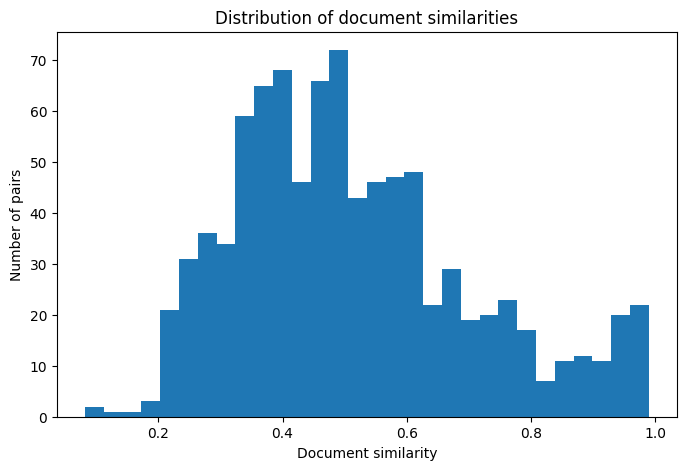

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(pairs_df['similarity'], bins=30)
plt.xlabel('Document similarity')
plt.ylabel('Number of pairs')
plt.title('Distribution of document similarities')
plt.show()